In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
house_df = pd.read_csv('housing.csv', index_col=None, header=0)
house_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
house_df.shape

(20640, 10)

In [4]:
house_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


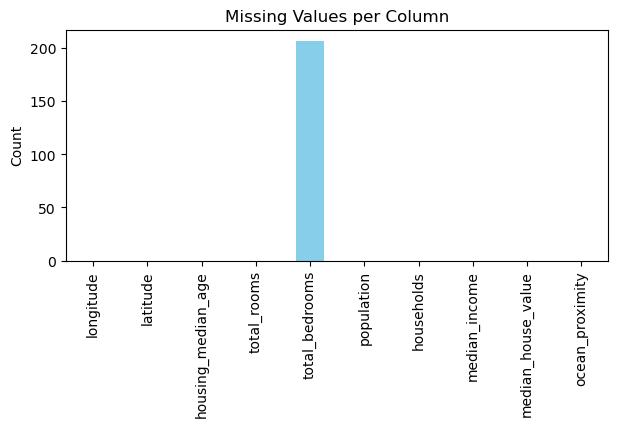

In [5]:
missing_value = house_df.isnull().sum()
print(missing_value)
missing_value.plot(kind='bar', figsize=(7, 3), color='skyblue')
plt.title('Missing Values per Column')
plt.ylabel('Count')
plt.show()

In [6]:
median_value_bedrooms = house_df['total_bedrooms'].median()
print('Median Value of total_bedrooms columns')
print(median_value_bedrooms)
house_df['total_bedrooms'].fillna(median_value_bedrooms, inplace=True)
print("")
print(house_df.isnull().sum())

Median Value of total_bedrooms columns
435.0

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


In [7]:
house_df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,536.838857,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,419.391878,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,297.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,643.250000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


<Axes: >

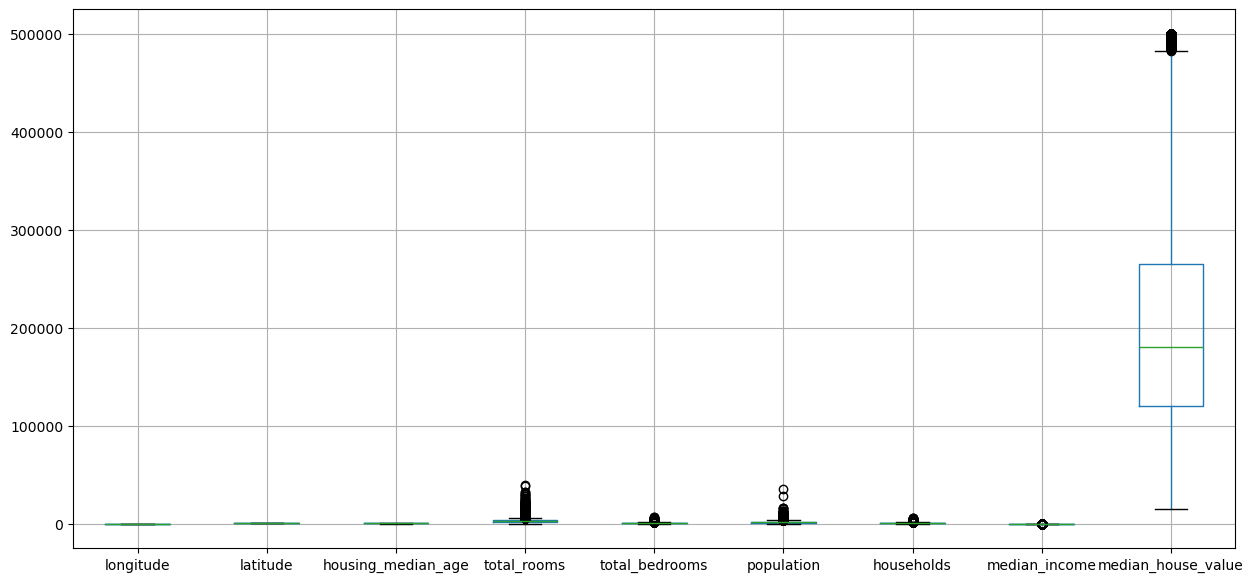

In [8]:
house_df.boxplot(figsize=(15,7))

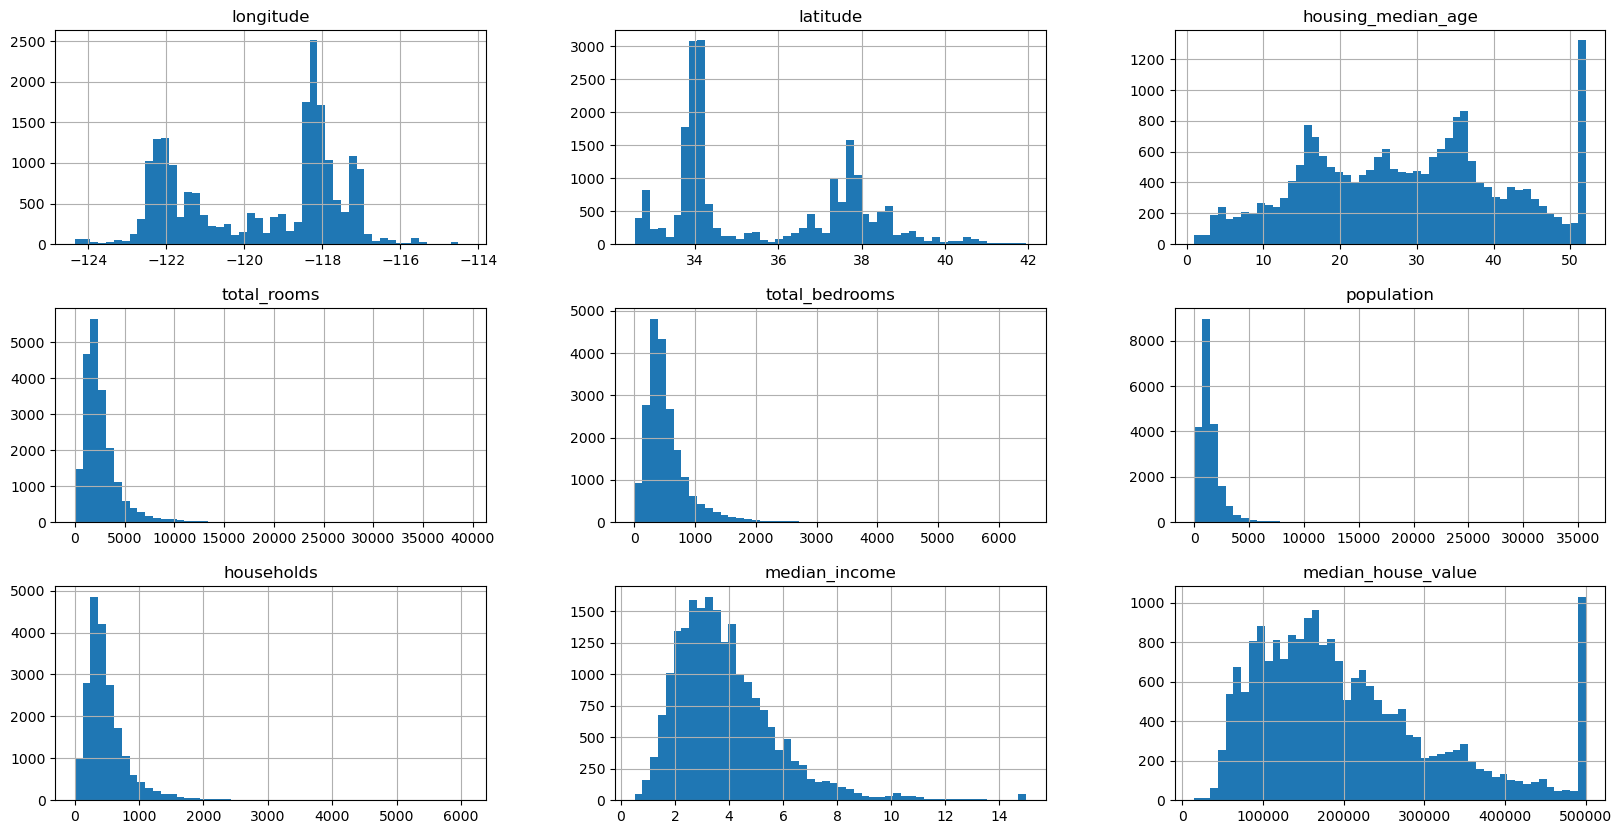

In [9]:
house_df.hist(bins=50, figsize=(20,10))
plt.show()

<Axes: >

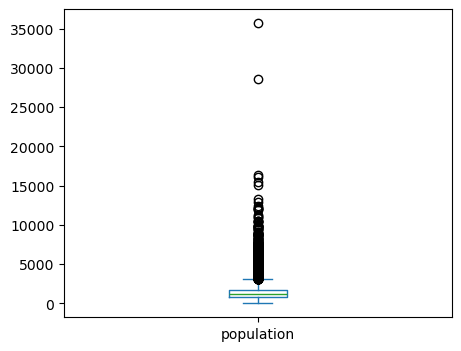

In [10]:
house_df['population'].plot(kind='box', figsize=(5,4))

<Axes: >

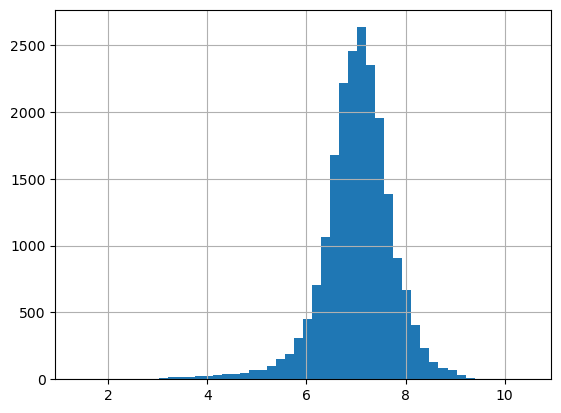

In [11]:
# Apply log transformation
house_df['population'] = np.log1p(house_df['population'])

# Check the new distribution
house_df['population'].hist(bins=50)

<Axes: >

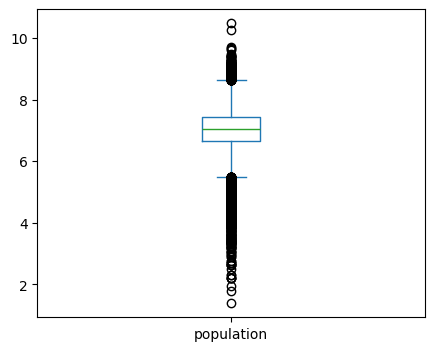

In [12]:
house_df['population'].plot(kind='box', figsize=(5,4))

<Axes: >

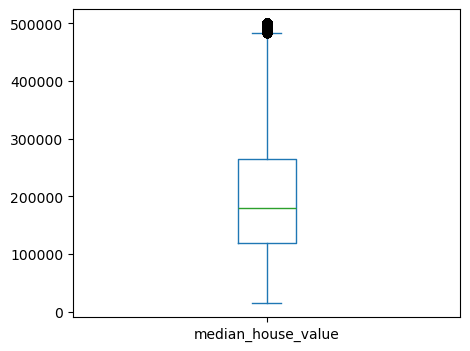

In [13]:
house_df['median_house_value'].plot(kind='box', figsize=(5,4))

<Axes: >

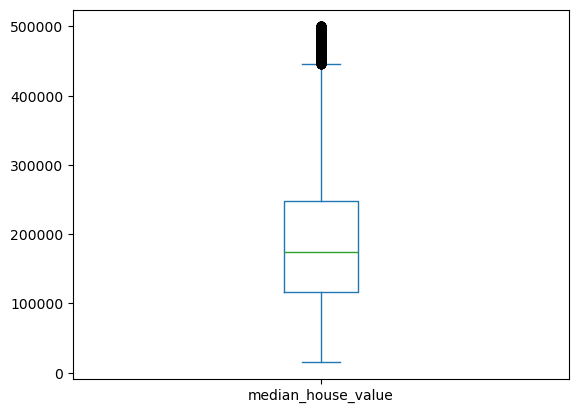

In [14]:
# Keep only the rows where the value is NOT capped
house_df = house_df[house_df['median_house_value'] < 500001]

# Now check the boxplot again
house_df['median_house_value'].plot(kind='box')

In [15]:
house_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19675 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           19675 non-null  float64
 1   latitude            19675 non-null  float64
 2   housing_median_age  19675 non-null  float64
 3   total_rooms         19675 non-null  float64
 4   total_bedrooms      19675 non-null  float64
 5   population          19675 non-null  float64
 6   households          19675 non-null  float64
 7   median_income       19675 non-null  float64
 8   median_house_value  19675 non-null  float64
 9   ocean_proximity     19675 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [16]:
house_df["rooms_per_household"] = house_df["total_rooms"] / house_df["households"]
house_df["bedrooms_per_room"] = house_df["total_bedrooms"] / house_df["total_rooms"]
house_df["population_per_household"] = house_df["population"] / house_df["households"]

In [17]:
house_df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     8604
INLAND        6524
NEAR OCEAN    2446
NEAR BAY      2096
ISLAND           5
Name: count, dtype: int64

In [18]:
from sklearn.preprocessing import OneHotEncoder
oh_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ocean_encoded = oh_encoder.fit_transform(house_df[['ocean_proximity']])
column_names = oh_encoder.get_feature_names_out(['ocean_proximity'])
encoded_df = pd.DataFrame(ocean_encoded, columns=column_names, index=house_df.index)
house_df = house_df.drop('ocean_proximity', axis=1)
house_df = pd.concat([house_df, encoded_df], axis=1)

In [19]:
house_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,5.777652,126.0,8.3252,452600.0,6.984127,0.146591,0.045854,0.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,7099.0,1106.0,7.784057,1138.0,8.3014,358500.0,6.238137,0.155797,0.006840,0.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467.0,190.0,6.208590,177.0,7.2574,352100.0,8.288136,0.129516,0.035077,0.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274.0,235.0,6.326149,219.0,5.6431,341300.0,5.817352,0.184458,0.028887,0.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627.0,280.0,6.338594,259.0,3.8462,342200.0,6.281853,0.172096,0.024473,0.0,0.0,0.0,1.0,0.0


In [20]:
house_df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'rooms_per_household', 'bedrooms_per_room',
       'population_per_household', 'ocean_proximity_<1H OCEAN',
       'ocean_proximity_INLAND', 'ocean_proximity_ISLAND',
       'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN'],
      dtype='object')

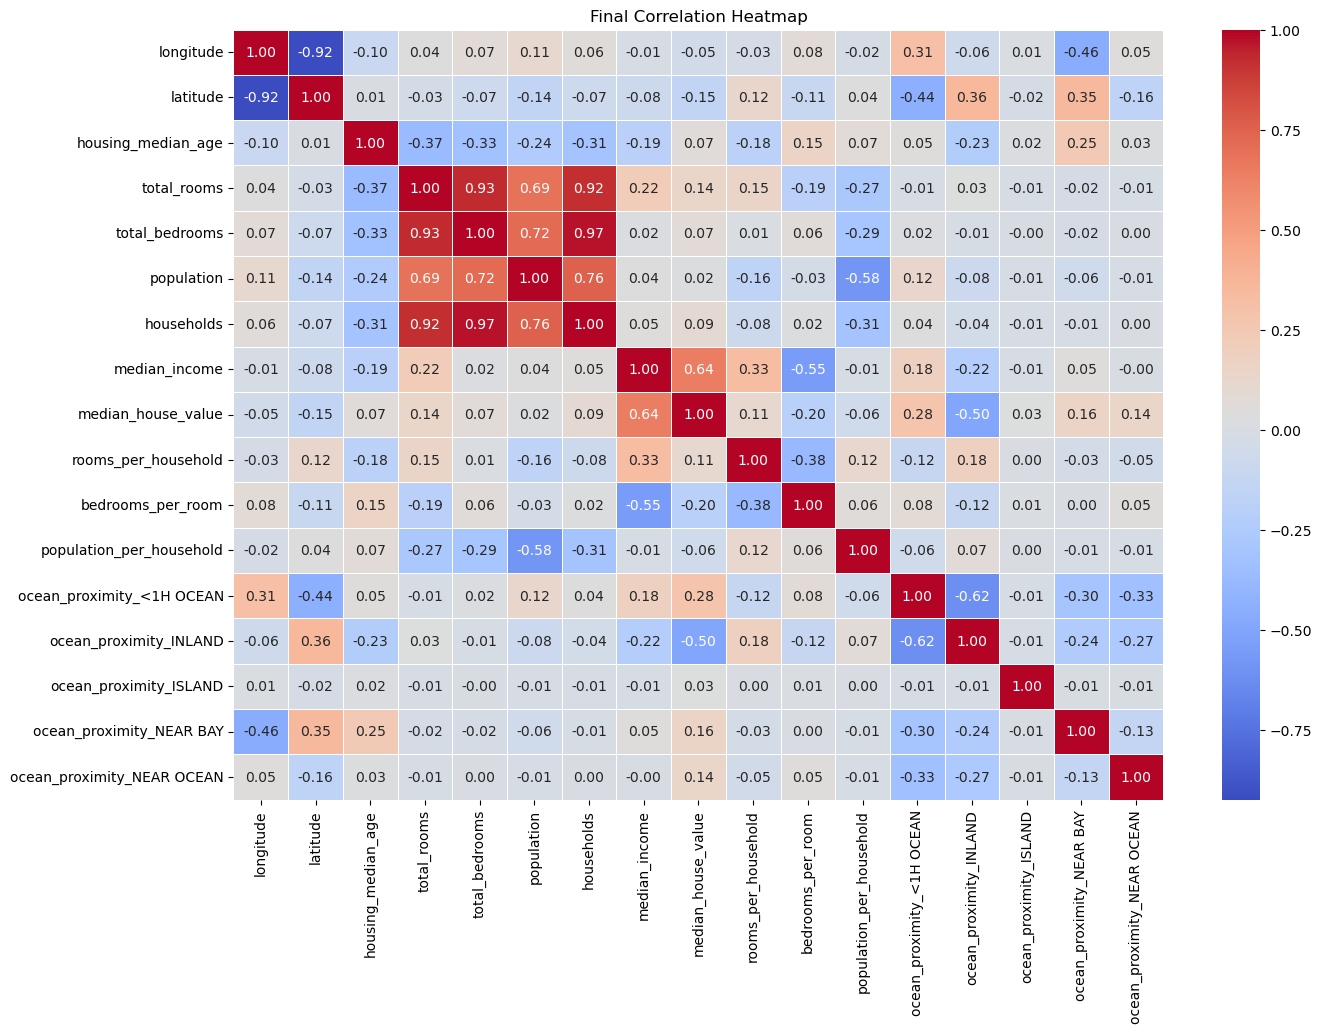

In [21]:
plt.figure(figsize=(15, 10))
sns.heatmap(house_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Final Correlation Heatmap')
plt.show()

In [22]:
X = house_df.drop("median_house_value", axis=1)
y = house_df["median_house_value"]

In [23]:
from sklearn.preprocessing import StandardScaler
scaler =  StandardScaler()
X_scaled = scaler.fit_transform(X)

In [24]:
from sklearn.model_selection import train_test_split

# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 15740
Testing set size: 3935


In [25]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print(lr.intercept_)
print(lr.coef_)

192468.61419149325
[-49070.13805402 -48130.07447064  11134.87988071 -18383.3057956
  21457.17396317 -21337.07516777  17374.38385556  62139.96353053
   3438.55079197   5369.20300223  -9531.21604085   6153.4465266
 -12048.75131362   3105.94276638   1896.79609884   6016.78733232]


In [26]:
print(list(zip(X.columns,lr.coef_)))

[('longitude', np.float64(-49070.13805402176)), ('latitude', np.float64(-48130.074470642634)), ('housing_median_age', np.float64(11134.879880708624)), ('total_rooms', np.float64(-18383.30579560352)), ('total_bedrooms', np.float64(21457.173963169305)), ('population', np.float64(-21337.07516776687)), ('households', np.float64(17374.383855562435)), ('median_income', np.float64(62139.96353052824)), ('rooms_per_household', np.float64(3438.550791971608)), ('bedrooms_per_room', np.float64(5369.203002231205)), ('population_per_household', np.float64(-9531.216040846712)), ('ocean_proximity_<1H OCEAN', np.float64(6153.446526604812)), ('ocean_proximity_INLAND', np.float64(-12048.751313617335)), ('ocean_proximity_ISLAND', np.float64(3105.9427663839933)), ('ocean_proximity_NEAR BAY', np.float64(1896.7960988415869)), ('ocean_proximity_NEAR OCEAN', np.float64(6016.78733232322))]


In [27]:
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y_test, lr_pred)
rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

n = len(y_test)
p = X_test.shape[1] 

adjusted_r_squared = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"R2 Score: {r2:.4f}")
print(f"Adjusted R2: {adjusted_r_squared:.4f}")
print(f"RMSE: ${rmse:,.2f}")

R2 Score: 0.6086
Adjusted R2: 0.6070
RMSE: $62,469.06


In [28]:
from sklearn.ensemble import RandomForestRegressor

# 1. Initialize the model
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Train the model (this might take a few seconds longer)
rf_reg.fit(X_train, y_train)

# 3. Predict and Score
rf_pred = rf_reg.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print(f"Random Forest R2: {rf_r2:.4f}")
print(f"Random Forest RMSE: ${rf_rmse:,.2f}")

Random Forest R2: 0.7873
Random Forest RMSE: $46,051.99


In [29]:
# Score on Training Data
train_pred = rf_reg.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
train_r2 = r2_score(y_train, train_pred)

print(f"Training R2: {train_r2:.4f} | Test R2: {rf_r2:.4f}")
print(f"Training RMSE: ${train_rmse:,.2f} | Test RMSE: ${rf_rmse:,.2f}")

Training R2: 0.9700 | Test R2: 0.7873
Training RMSE: $16,831.93 | Test RMSE: $46,051.99


In [30]:
# We limit max_depth and set min_samples_leaf to prevent the trees from memorizing noise
rf_reg_tuned = RandomForestRegressor(
    n_estimators=100, 
    max_depth=20,           # Stop trees from growing infinitely deep
    min_samples_leaf=5,     # Each "leaf" must have at least 5 houses
    max_features='sqrt',    # Only look at a random subset of features for each split
    random_state=42
)

rf_reg_tuned.fit(X_train, y_train)

# Now check the scores again
train_pred_tuned = rf_reg_tuned.predict(X_train)
test_pred_tuned = rf_reg_tuned.predict(X_test)

print(f"Tuned Training R2: {r2_score(y_train, train_pred_tuned):.4f}")
print(f"Tuned Test R2: {r2_score(y_test, test_pred_tuned):.4f}")

Tuned Training R2: 0.8742
Tuned Test R2: 0.7600


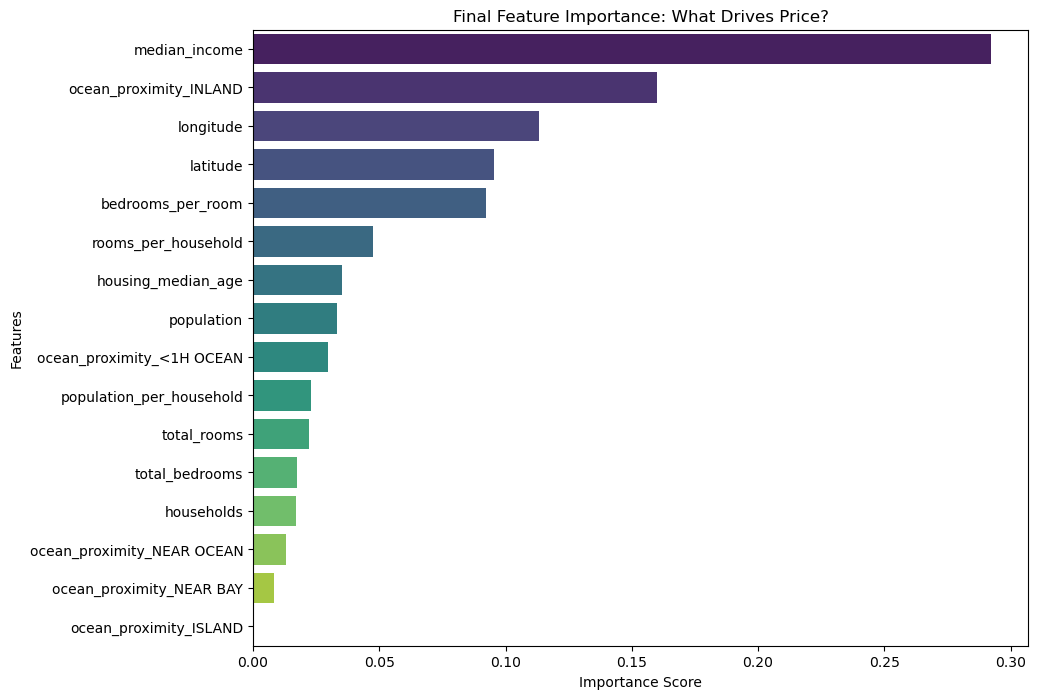

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract importance
importances = rf_reg_tuned.feature_importances_
feature_names = X.columns # Ensure X is your dataframe with all feature names

# Create a summary dataframe
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Final Feature Importance: What Drives Price?')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

In [32]:
# Keep original important ones
X = house_df[[
    "median_income",
    "longitude",
    "latitude",
    "rooms_per_household",
    "bedrooms_per_room",
    "population_per_household",
    "housing_median_age",
    "ocean_proximity_INLAND",
    "ocean_proximity_<1H OCEAN",
    "ocean_proximity_NEAR OCEAN",
]]

# Add new engineered features
X["income_per_room"] = house_df["median_income"] / house_df["total_rooms"]
X["bedroom_density"] = house_df["total_bedrooms"] / house_df["population"]

In [33]:
X.head()

,median_income,longitude,latitude,rooms_per_household,bedrooms_per_room,population_per_household,housing_median_age,ocean_proximity_INLAND,ocean_proximity_<1H OCEAN,ocean_proximity_NEAR OCEAN,income_per_room,bedroom_density
0,8.3252,-122.23,37.88,6.984127,0.146591,0.045854,41.0,0.0,0.0,0.0,0.009460,22.327408
1,8.3014,-122.22,37.86,6.238137,0.155797,0.006840,21.0,0.0,0.0,0.0,0.001169,142.085290
2,7.2574,-122.24,37.85,8.288136,0.129516,0.035077,52.0,0.0,0.0,0.0,0.004947,30.602762
3,5.6431,-122.25,37.85,5.817352,0.184458,0.028887,52.0,0.0,0.0,0.0,0.004429,37.147399
4,3.8462,-122.25,37.85,6.281853,0.172096,0.024473,52.0,0.0,0.0,0.0,0.002364,44.173834


In [34]:
X.columns

Index(['median_income', 'longitude', 'latitude', 'rooms_per_household',
       'bedrooms_per_room', 'population_per_household', 'housing_median_age',
       'ocean_proximity_INLAND', 'ocean_proximity_<1H OCEAN',
       'ocean_proximity_NEAR OCEAN', 'income_per_room', 'bedroom_density'],
      dtype='object')

In [35]:
from sklearn.preprocessing import StandardScaler
scaler =  StandardScaler()
X_scaled = scaler.fit_transform(X)

In [36]:
from sklearn.model_selection import train_test_split

# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 15740
Testing set size: 3935


In [37]:
from sklearn.ensemble import RandomForestRegressor

# 1. Initialize the model
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Train the model (this might take a few seconds longer)
rf_reg.fit(X_train, y_train)

# 3. Predict and Score
rf_pred = rf_reg.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print(f"Random Forest R2: {rf_r2:.4f}")
print(f"Random Forest RMSE: ${rf_rmse:,.2f}")

Random Forest R2: 0.7840
Random Forest RMSE: $46,403.10


In [38]:
y.head()

0    452600.0
1    358500.0
2    352100.0
3    341300.0
4    342200.0
Name: median_house_value, dtype: float64

In [39]:
rf_reg_tuned = RandomForestRegressor(
    n_estimators=300, 
    max_depth=20,           # Stop trees from growing infinitely deep
    min_samples_leaf=2,     # Each "leaf" must have at least 5 houses
    min_samples_split=5,
    max_features='sqrt',    # Only look at a random subset of features for each split
    random_state=42,
    n_jobs=-1
)

rf_reg_tuned.fit(X_train, y_train)

# Now check the scores again
train_pred_tuned = rf_reg_tuned.predict(X_train)
test_pred_tuned = rf_reg_tuned.predict(X_test)

print(f"Tuned Training R2: {r2_score(y_train, train_pred_tuned):.4f}")
print(f"Tuned Test R2: {r2_score(y_test, test_pred_tuned):.4f}")

Tuned Training R2: 0.9259
Tuned Test R2: 0.7650


In [40]:
#!pip install xgboost

In [41]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
)

xgb.fit(X_train, y_train)

ValueError: feature_names must be string, and may not contain [, ] or <